This is an earlier mock-up of the project I did. My code ran a bit too slow, so I used AI to make some of the annoying bits run a bit faster, like sampling and interpolation. 

## Bessel Modal Decomposition on a Disk

Like 1D functions, a function $ f(r, \theta) $ can be represented as a sum of 2D orthogonal functions. We could use entirely bessel functions, but a bit of fourier magic makes the plot converge better.

$$
\psi_{nm}(r, \theta) = J_n(\alpha_{nm} r) e^{i n \theta}
$$

### Orthogonality Conditions

Angular orthogonality (Fourier series basis):
$$
\int_0^{2\pi} e^{i n \theta} e^{-i n' \theta}  d\theta = 2\pi \, \delta_{nn'}
$$

Radial orthogonality requires $ J_n(\alpha_{nm}) = 0 $, where $ \alpha_{nm} $ is the $ m$-th root of $ J_n $. Then:
$$
\int_0^1 J_n(\alpha_{nm} r) J_n(\alpha_{nm'} r)  r  dr = \frac{\delta_{mm'}}{2} [J_{n+1}(\alpha_{nm})]^2
$$

Notice the $r$ included as well. Unlike fourier series, orthogonality only occurs at zeros, so we find them using `jn_zeros(n, m)` and rescale by $x$.

`scipy.special.jn_zeros(n, m)` returns the first $ m $ roots $ \alpha_{n1}, \alpha_{n2}, \dots, \alpha_{nm} $ of $ J_n(x) = 0 $.

### Modal Coefficients & Reconstruction

To find each $a_{nm}$ just do the overlap integral and renormalize with the coefficient on $\delta_{ij}$
$$
a_{nm} = \frac{2}{\pi [J_{n+1}(\alpha_{nm})]^2} \int_0^{2\pi} \int_0^1 f(r, \theta) J_n(\alpha_{nm} r) e^{-i n \theta} r  dr  d\theta
$$

The function is reconstructed as:
$$
f(r, \theta) \approx \sum_{n=-N}^{N} \sum_{m=1}^{M} a_{nm} J_n(\alpha_{nm} r) e^{i n \theta}
$$

In [1]:
import numpy as np
from scipy.special import jn, jn_zeros
import matplotlib.pyplot as plt

def compute_a_nm_vectorized(f, R, N=5, M=5, Nr=200, Ntheta=360):
    """
    Vectorized computation of Fourier-Bessel coefficients a_nm for a 2D function f(r,theta)
    """
    r = np.linspace(0, R, Nr)
    theta = np.linspace(0, 2*np.pi, Ntheta)
    dr = R / (Nr-1)
    dtheta = 2*np.pi / Ntheta
    rr, tt = np.meshgrid(r, theta, indexing='ij')
    f_vals = f(rr, tt, R)  # samples Nradius*Ntheta times (Total! Not really a bottleneck)

    # initialize
    a_nm = np.zeros((N, M), dtype=complex)

    for n in range(N):
        alpha_nm = jn_zeros(n, M)  # zeros of J_n
        k_nm = alpha_nm / R        # orthogonality is only on [0, R] so R is the maximum r-value

        # Precompute Bessel functions
        J_vals = jn(n, np.outer(r, k_nm))  # the correct way to do r[:, None] * k_nm[None, :]

        # Precompute Fourier functions
        exp_n_theta = np.exp(-1j * n * theta)

        # use vectorization magic to do faster computation
        f_theta = f_vals * exp_n_theta[None, :] 
        int_theta = np.sum(f_theta, axis=1) * dtheta  
        integrand = int_theta[:, None] * J_vals * r[:, None]
        integral = np.sum(integrand, axis=0) * dr 

        # Normalization
        norm = (R**2 / 2) * (jn(n+1, alpha_nm)**2)
        a_nm[n, :] = integral / norm

    return a_nm

def recon_from_a_nm_vectorized(a_nm, R, r, theta):
    """
    Vectorized reconstruction from Fourier-Bessel coefficients
    """
    rr, tt = np.meshgrid(r, theta, indexing='ij')
    f_recon = np.zeros_like(rr, dtype=complex)

    N, M = a_nm.shape

    for n in range(N):
        alpha_nm = jn_zeros(n, M)
        k_nm = alpha_nm / R
        J_vals = jn(n, np.outer(r, k_nm))
        exp_n_theta = np.exp(1j * n * theta)
        f_n = J_vals @ a_nm[n, :] 
        f_recon += f_n[:, None] * exp_n_theta[None, :]

    return f_recon


In [2]:
%matplotlib widget

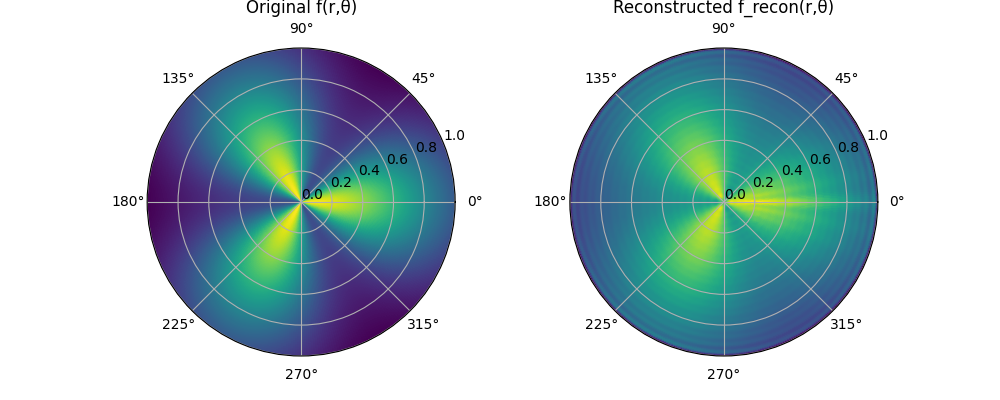

In [ ]:

def f_mixed(r, theta, R):
    return np.exp(-(r/R)**2) * (1 + 0.5*np.cos(3*theta))

# parameters
R = 1.0
N, M = 40, 40
Nr, Ntheta = 400, 400
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)

a_nm = compute_a_nm_vectorized(f_mixed, R, N, M, Nr, Ntheta)
f_recon = recon_from_a_nm_vectorized(a_nm, R, r, theta)

rr, tt = np.meshgrid(r, theta, indexing='ij')
f_true = f_mixed(rr, tt, R)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'polar'})
ax[0].pcolormesh(tt, rr, np.real(f_true), shading='auto')
ax[0].set_title("Original f(r,θ)")
ax[1].pcolormesh(tt, rr, np.real(f_recon), shading='auto')
ax[1].set_title("Reconstructed f_recon(r,θ)")
plt.show()


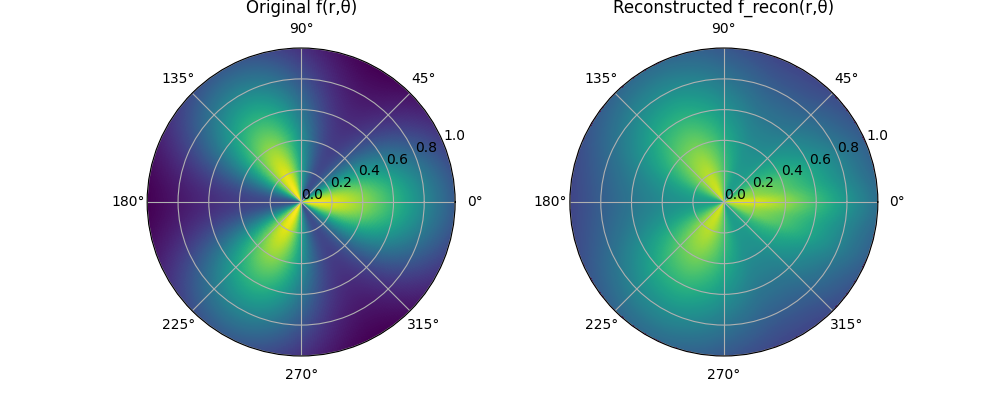

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from scipy.special import jn, jn_zeros

def test_func(r, theta, R):
    return np.exp(-(r/R)**2) * (1 + 0.5*np.cos(3*theta))

R = 1.0
N_max, M_max = 20, 400
Nr, Ntheta = 400, 400

r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
rr, tt = np.meshgrid(r, theta, indexing='ij')
f_true = test_func(rr, tt, R)

# -------------------------
# Vectorized coefficient computation
# -------------------------
def compute_a_nm_vectorized(f, R, N=20, M=20, Nr=200, Ntheta=200):
    r = np.linspace(0, R, Nr)
    theta = np.linspace(0, 2*np.pi, Ntheta)
    dr = R / (Nr-1)
    dtheta = 2*np.pi / Ntheta
    rr, tt = np.meshgrid(r, theta, indexing='ij')
    f_vals = f(rr, tt, R)
    
    a_nm = np.zeros((N, M), dtype=complex)
    J_vals_all = np.zeros((N, M, Nr))
    exp_n_theta = np.zeros((N, Ntheta), dtype=complex)
    
    for n in range(N):
        alpha_nm = jn_zeros(n, M)
        k_nm = alpha_nm / R
        J_vals_all[n,:,:] = jn(n, np.outer(r, k_nm)).T
        exp_n_theta[n,:] = np.exp(-1j * n * theta)
        
        for m_idx, alpha in enumerate(alpha_nm):
            basis = J_vals_all[n, m_idx, :][:, None] * exp_n_theta[n,:][None, :]
            integrand = f_vals * np.conj(basis) * rr
            integral = np.sum(integrand) * dr * dtheta
            norm = (R**2 / 2) * (jn(n+1, alpha)**2)
            a_nm[n,m_idx] = integral / norm
    return a_nm, J_vals_all, exp_n_theta

# Precompute
a_nm, J_vals_all, exp_n_theta = compute_a_nm_vectorized(test_func, R, N_max, M_max, Nr, Ntheta)

# -------------------------
# Incremental reconstruction
# -------------------------
def recon_partial(n_max, m_max):
    f_recon = np.zeros((Nr, Ntheta), dtype=complex)
    for n in range(n_max+1):
        J_slice = J_vals_all[n,:m_max+1,:]  # shape (m_max+1, Nr)
        a_slice = a_nm[n,:m_max+1]          # shape (m_max+1,)
        f_r = (J_slice.T @ a_slice)         # shape (Nr,)
        f_recon += f_r[:, None] * np.exp(1j*n*theta)[None,:]
    return f_recon


f_recon= recon_partial(N_max-1, M_max-1)

# plot real parts
fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'polar'})
ax[0].pcolormesh(tt, rr, np.real(f_true), shading='auto')
ax[0].set_title("Original f(r,θ)")
ax[1].pcolormesh(tt, rr, np.real(f_recon), shading='auto')
ax[1].set_title("Reconstructed f_recon(r,θ)")
plt.show()


interactive(children=(IntSlider(value=0, description='n_max', max=19), IntSlider(value=0, description='m_max',…

<function __main__.update(n_max=0, m_max=0)>

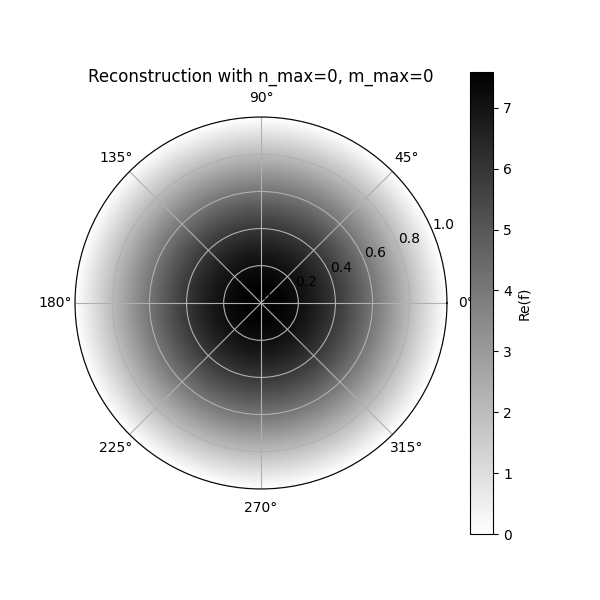

In [5]:
plt.close('all')

# -------------------------
# Polar plot setup
# -------------------------
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection':'polar'})
c = ax.pcolormesh(tt, rr, np.real(f_true), shading='auto', cmap='binary')
ax.set_title("Fourier-Bessel Reconstruction (Polar)")
fig.colorbar(c, ax=ax, label='Re(f)')

# -------------------------
# Slider update function
# -------------------------
def update(n_max=0, m_max=0):
    f_recon = recon_partial(n_max, m_max)
    # Use magnitude to avoid negative/oscillation extremes
    data_to_plot = np.abs(f_recon)
    c.set_array(data_to_plot.ravel())
    # Update color limits dynamically
    c.set_clim(0, np.max(data_to_plot))
    ax.set_title(f'Reconstruction with n_max={n_max}, m_max={m_max}')
    fig.canvas.draw_idle()

interact(update,
         n_max=IntSlider(min=0,max=N_max-1,value=0, description='n_max'),
         m_max=IntSlider(min=0,max=M_max-1,value=0, description='m_max'))

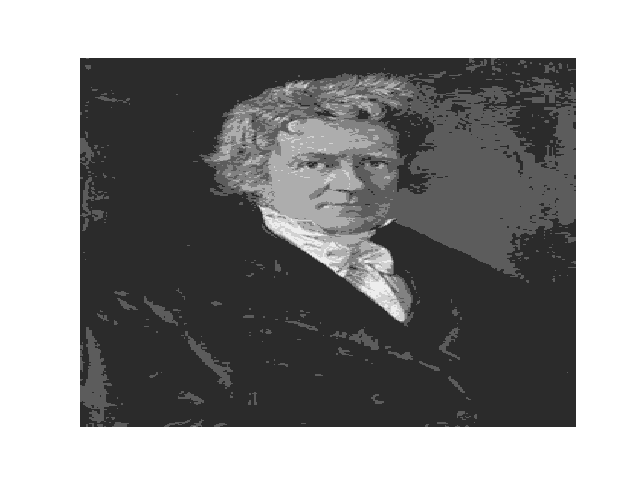

In [13]:
from PIL import Image
import seaborn as sns
from matplotlib.colors import ListedColormap

grayscale = sns.color_palette(palette='Greys')
grayscale.reverse()
gray_cmap = ListedColormap(grayscale)

img = Image.open('Friedrich_Wilhelm_Bessel_(1839_painting).jpg').convert('L')
img = np.asarray(img)

plt.figure()
sns.heatmap(img, cmap=grayscale, xticklabels=False, yticklabels=False, cbar=False)
plt.show()

In [7]:
plt.close('all')

In [8]:
img.shape

(395, 325)

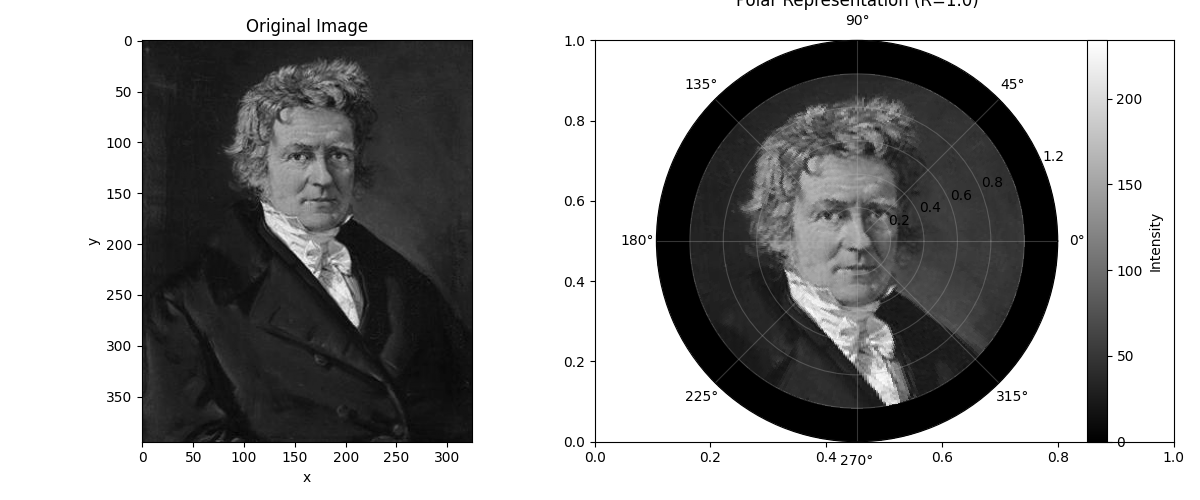

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

class PolarSampler:
    def __init__(self, image, center=None):
        self.image = image
        if center is None:
            self.center = (image.shape[1] // 2, image.shape[0] // 2)
        else:
            self.center = center
        
        self.x0, self.y0 = self.center
        self.max_r = min(self.x0, self.y0, 
                        image.shape[1] - self.x0, 
                        image.shape[0] - self.y0)
    
    def __call__(self, r, theta, R=1.0):
        r = np.asarray(r)
        theta = np.asarray(theta)
        
        if r.shape != theta.shape:
            if r.size == 1:
                r = np.full_like(theta, r)
            elif theta.size == 1:
                theta = np.full_like(r, theta)
            else:
                raise ValueError("r and theta must have compatible shapes")
        
        r_abs = r * (self.max_r / R)
        valid_mask = r <= R
        result = np.zeros_like(r_abs, dtype=self.image.dtype)
        
        if np.any(valid_mask):
            x = self.x0 + r_abs[valid_mask] * np.cos(theta[valid_mask])
            y = self.y0 + r_abs[valid_mask] * np.sin(theta[valid_mask])
            
            coordinates = np.array([y, x])
            sampled_values = map_coordinates(self.image, coordinates, 
                                           order=1, mode='constant', cval=0.0)
            result[valid_mask] = sampled_values
        
        if result.size == 1:
            return result.item()
        return result

# Create your polar sampler
f = PolarSampler(img, center=(175, 135))

# Create polar coordinate grid for pcolormesh
def create_polar_mesh(r_max=1.0, r_resolution=100, theta_resolution=360, R=1.0):
    """
    Create meshgrid for polar pcolormesh
    
    Returns:
    - r_edges, theta_edges: Edge coordinates for pcolormesh
    - r_centers, theta_centers: Center coordinates for sampling
    """
    # Create edge coordinates (one more than centers)
    r_edges = np.linspace(0, r_max, r_resolution + 1)
    theta_edges = np.linspace(0, 2 * np.pi, theta_resolution + 1)
    
    # Create center coordinates (for sampling)
    r_centers = (r_edges[:-1] + r_edges[1:]) / 2
    theta_centers = (theta_edges[:-1] + theta_edges[1:]) / 2
    
    # Create meshgrids
    R_edges, Theta_edges = np.meshgrid(r_edges, theta_edges)
    R_centers, Theta_centers = np.meshgrid(r_centers, theta_centers)
    
    return (R_edges, Theta_edges), (R_centers, Theta_centers)

# Create the polar mesh
(r_edges, theta_edges), (r_centers, theta_centers) = create_polar_mesh(
    r_max=1.2, r_resolution=200, theta_resolution=360, R=1.0
)

# Sample the image at the polar grid centers
polar_data = f(r_centers, theta_centers, R=1.0)

# Create the polar plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original image
ax1.imshow(img, cmap='gray')
ax1.set_title('Original Image')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# Polar plot
ax2 = plt.subplot(1, 2, 2, projection='polar')
im = ax2.pcolormesh(-theta_edges, r_edges, polar_data, cmap='gray', shading='auto')

# Customize polar plot
ax2.set_theta_zero_location('E')  # 0° points East (right)
ax2.set_theta_direction(1)  # Angles increase counterclockwise
ax2.set_title('Polar Representation (R=1.0)')
ax2.grid(True, alpha=0.3)

# Add colorbar
plt.colorbar(im, ax=ax2, label='Intensity')

plt.tight_layout()
plt.show()

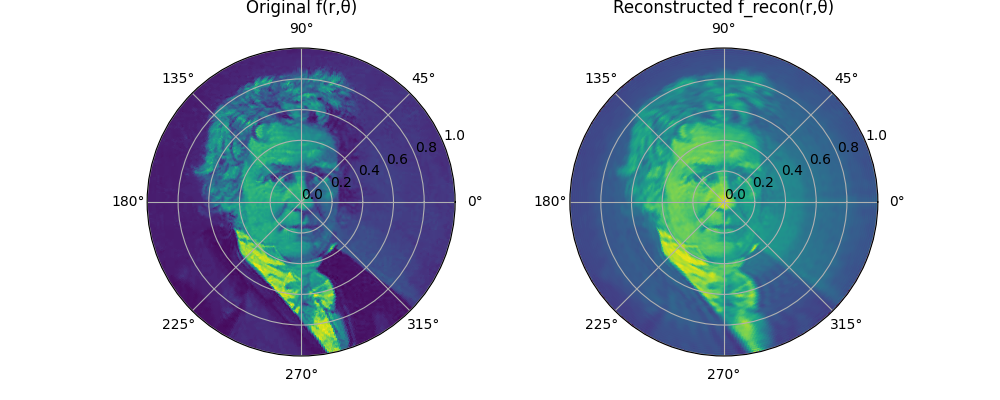

In [10]:

# -------------------------
# Example function
# -------------------------
def test_func(r, theta, R):
    return f(r, theta, R)
# -------------------------
# Parameters
# -------------------------
R = 1.0
N_max, M_max = 60, 150
Nr, Ntheta = 300, 600

r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
rr, tt = np.meshgrid(r, theta, indexing='ij')
f_true = test_func(rr, tt, R)

# -------------------------
# Vectorized coefficient computation
# -------------------------
def compute_a_nm_vectorized(f, R, N=20, M=20, Nr=200, Ntheta=200):
    r = np.linspace(0, R, Nr)
    theta = np.linspace(0, 2*np.pi, Ntheta)
    dr = R / (Nr-1)
    dtheta = 2*np.pi / Ntheta
    rr, tt = np.meshgrid(r, theta, indexing='ij')
    f_vals = f(rr, tt, R)
    
    a_nm = np.zeros((N, M), dtype=complex)
    J_vals_all = np.zeros((N, M, Nr))
    exp_n_theta = np.zeros((N, Ntheta), dtype=complex)
    
    for n in range(N):
        alpha_nm = jn_zeros(n, M)
        k_nm = alpha_nm / R
        J_vals_all[n,:,:] = jn(n, np.outer(r, k_nm)).T
        exp_n_theta[n,:] = np.exp(-1j * n * theta)
        
        for m_idx, alpha in enumerate(alpha_nm):
            basis = J_vals_all[n, m_idx, :][:, None] * exp_n_theta[n,:][None, :]
            integrand = f_vals * np.conj(basis) * rr
            integral = np.sum(integrand) * dr * dtheta
            norm = (R**2 / 2) * (jn(n+1, alpha)**2)
            a_nm[n,m_idx] = integral / norm
    return a_nm, J_vals_all, exp_n_theta

# Precompute
a_nm, J_vals_all, exp_n_theta = compute_a_nm_vectorized(test_func, R, N_max, M_max, Nr, Ntheta)

# -------------------------
# Incremental reconstruction
# -------------------------
def recon_partial(n_max, m_max):
    f_recon = np.zeros((Nr, Ntheta), dtype=complex)
    for n in range(n_max+1):
        J_slice = J_vals_all[n,:m_max+1,:]  # shape (m_max+1, Nr)
        a_slice = a_nm[n,:m_max+1]          # shape (m_max+1,)
        f_r = (J_slice.T @ a_slice)         # shape (Nr,)
        f_recon += f_r[:, None] * np.exp(1j*n*theta)[None,:]
    return f_recon


f_recon= recon_partial(N_max-1, M_max-1)

# plot real parts
fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'polar'})
ax[0].pcolormesh(-tt, rr, np.real(f_true), shading='auto')
ax[0].set_title("Original f(r,θ)")
ax[1].pcolormesh(tt, rr, np.real(f_recon), shading='auto')
ax[1].set_title("Reconstructed f_recon(r,θ)")
plt.show()


interactive(children=(IntSlider(value=0, description='n_max', max=59), IntSlider(value=0, description='m_max',…

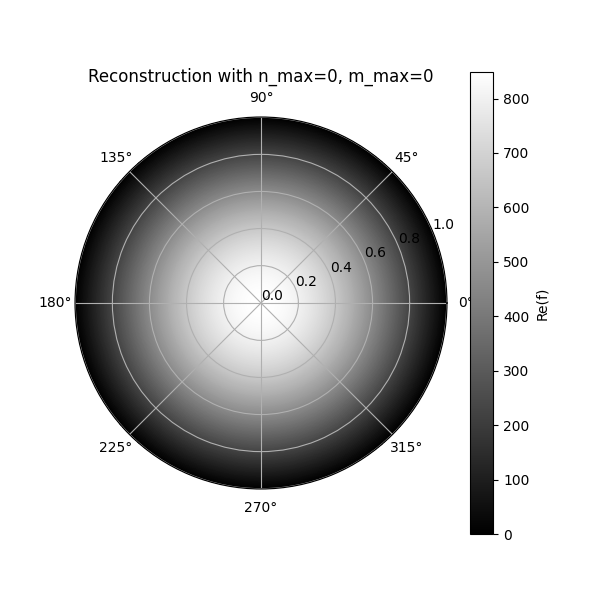

In [11]:
plt.close('all')

# -------------------------
# Polar plot setup
# -------------------------
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection':'polar'})
c = ax.pcolormesh(tt, rr, np.real(f_true), shading='auto', cmap='gray')
ax.set_title("Fourier-Bessel Reconstruction (Polar)")
fig.colorbar(c, ax=ax, label='Re(f)')

# -------------------------
# Slider update function
# -------------------------
def update(n_max=0, m_max=0):
    f_recon = recon_partial(n_max, m_max)
    # Use magnitude to avoid negative/oscillation extremes
    data_to_plot = np.abs(f_recon)
    c.set_array(data_to_plot.ravel())
    # Update color limits dynamically
    c.set_clim(0, np.max(data_to_plot))
    ax.set_title(f'Reconstruction with n_max={n_max}, m_max={m_max}')
    fig.canvas.draw_idle()

interact(update,
         n_max=IntSlider(min=0,max=N_max-1,value=0, description='n_max'),
         m_max=IntSlider(min=0,max=M_max-1,value=0, description='m_max'));

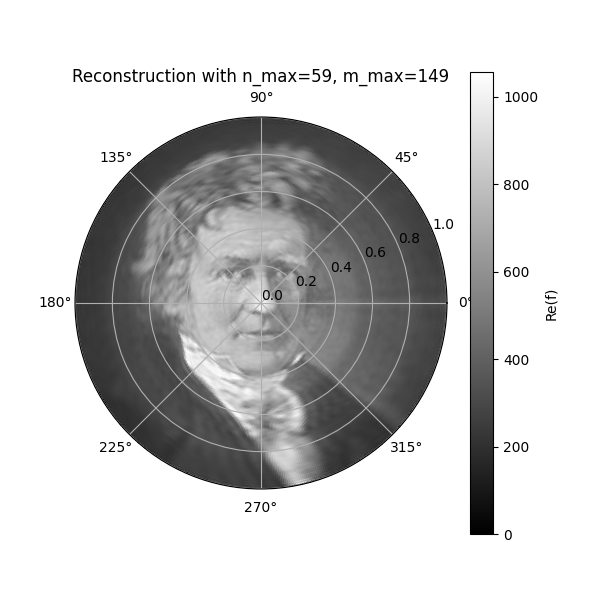

In [12]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
import numpy as np

plt.close('all')

# -------------------------
# Polar plot setup
# -------------------------
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection':'polar'})
c = ax.pcolormesh(tt, rr, np.real(f_true), shading='auto', cmap='gray')
ax.set_title("Fourier-Bessel Reconstruction (Polar)")
fig.colorbar(c, ax=ax, label='Re(f)')

# -------------------------
# Animation function
# -------------------------
def animate(frame):
    nm_max = frame
    n_max = int(N_max * nm_max / max(N_max, M_max))
    m_max = int(M_max * nm_max / max(N_max, M_max))

    f_recon = recon_partial(n_max, m_max)
    # Use magnitude to avoid negative/oscillation extremes
    data_to_plot = np.abs(f_recon)
    c.set_array(data_to_plot.ravel())
    # Update color limits dynamically
    c.set_clim(0, np.max(data_to_plot))
    ax.set_title(f'Reconstruction with n_max={n_max}, m_max={m_max}')
    return [c]

# Create animation
frames = max(N_max, M_max)
anim = animation.FuncAnimation(fig, animate, frames=frames, 
                              interval=100, blit=True, repeat=True)

# Save as GIF
writer = PillowWriter(fps=10)
anim.save('fourier_bessel_reconstruction.gif', writer=writer)

plt.show()